In [1]:
# imports needed to compute things
import numpy as np
from mfpy.utils import label_series
from mfpy.clustering import SegmentBasedCluster

# imports needed to visualize things
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# load data, ground truth
filename = "../../../data/Toy_Model_Trajectories/sigma_20_transition_25.txt"
gt_filename= "../../../data/Toy_Model_Trajectories/sigma_20_transition_25_GroundTruth.txt"
gt = np.loadtxt(gt_filename)
data = np.loadtxt(filename)
data = np.reshape(data, (data.shape[0], 1))

In [2]:
T = data.shape[0]
l = 0*T
u = -1
x = data[l:u]
w=np.array([25])
q=np.array([0.95])
cp_sbc = SegmentBasedCluster(window_size=w, quantile=q)
cp_sbc.fit(x)

100%|██████████████████████████████████████| 780/780 [00:00<00:00, 10979.08it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/dadapy/kstar.py:101: UserWarning: Careful! The intrinsic dimension is not defined. Computing it unsupervisedly with 'compute_id_2NN()' method
  warnings.warn(


SegmentBasedCluster(quantile=array([0.95]), window_size=array([25]))

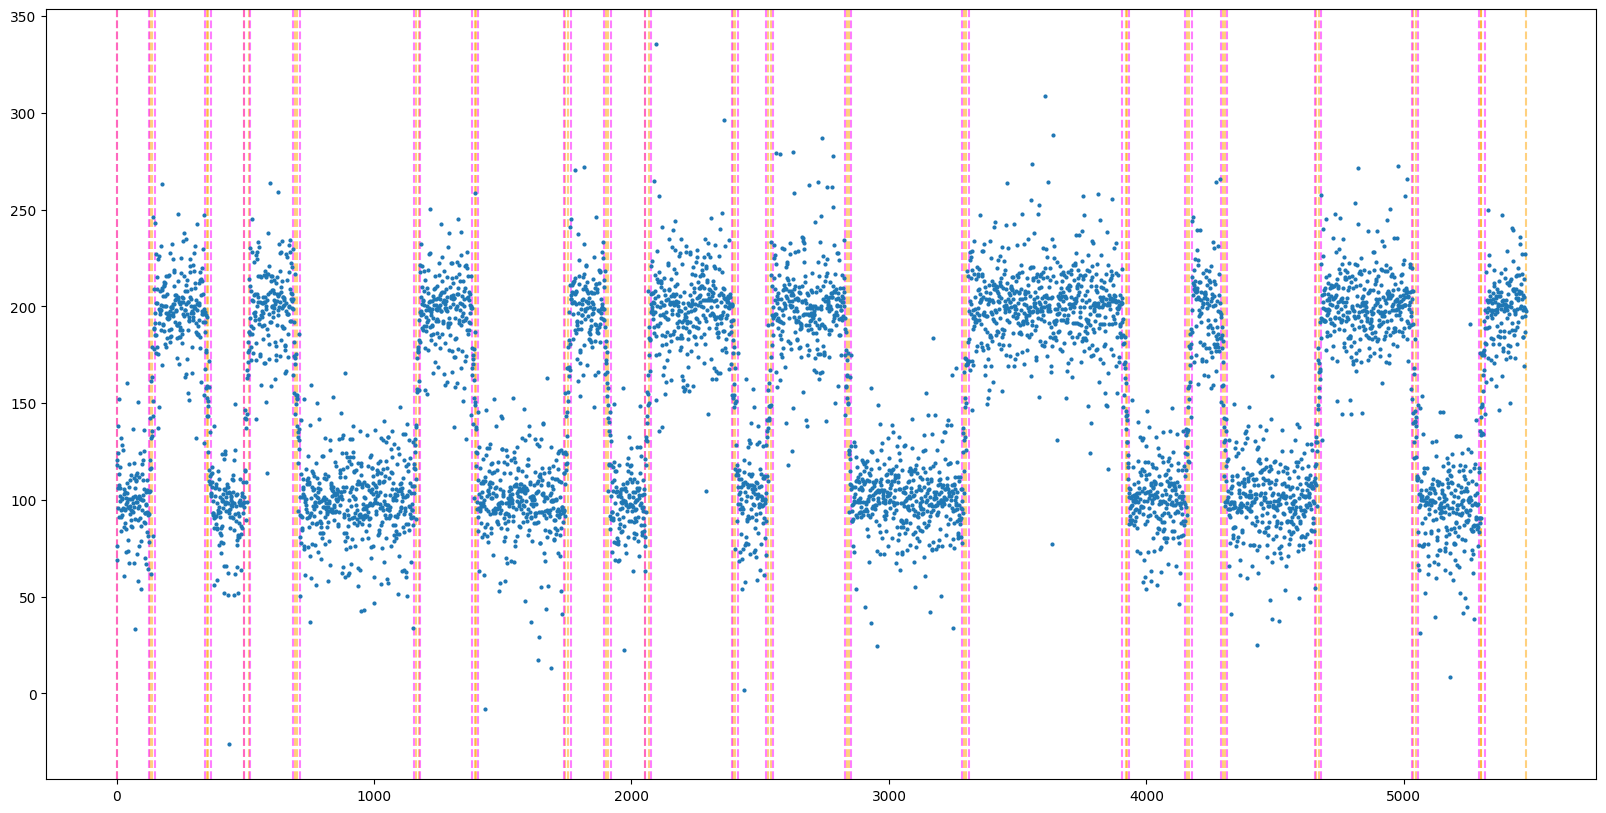

In [3]:
times = range(x.shape[0])
cps = cp_sbc.change_points_[:,0]
cp_df = pd.DataFrame(
    {"time": times,
     "value": x[:,0],
     "label": cp_sbc.point_labels_,
     "predicted_cp": cps,
     "true_cp": [1 if t in gt else 0 for t in times],
     }
)
df = cp_df
fig = plt.figure(figsize=(20,10))
plt.scatter(df['time'], df['value'], s=4, rasterized=True)
for t in df[df['predicted_cp'] == 1]['time']:
    plt.axvline(t, color='orange', linestyle='--', alpha=0.5, zorder=0)
for t in df[df['true_cp'] == 1]['time']:
    plt.axvline(t, color='magenta', linestyle='--', alpha=0.5, zorder=0)
plt.savefig("toy-cps.pdf")
plt.show()

In [4]:
true_transition_ranges = [(gt[i], gt[i + 1]) for i in range(1, gt.shape[0]-1, 2)] 
true_positives = []
distance_from_truth = []
for t in df[df['predicted_cp'] == 1]['time']:
    for region in true_transition_ranges:
        if t > region[0] and t < region[1]:
            true_positives.append(t)
            distance_from_truth.append(np.min(np.abs([t - region[0],t - region[1]])))
            break

In [5]:
cps = df[df['predicted_cp'] == 1]['time'].to_numpy()
ground_truth = df[df['true_cp'] == 1]['time'].to_numpy()
ground_truth[1] - cps

array([  125,    -5,   -14,  -227,  -232,  -370,  -388,  -569,  -575,
       -1039, -1048, -1268, -1272, -1617, -1630, -1776, -1785, -1929,
       -1942, -2270, -2279, -2405, -2417, -2713, -2719, -3167, -3173,
       -3795, -3798, -4033, -4041, -4172, -4180, -4535, -4547, -4910,
       -4923, -5175, -5176, -5348])

In [6]:
def true_positives(ground_truth, change_points, tol):
    tp = 0
    for t in ground_truth:
        if np.min(np.abs(t - change_points)) < tol:
            tp += 1
    return tp

tps = [true_positives(ground_truth, cps, k) for k in range(100)]
precision = [tp / len(cps) for tp in tps]
recall = [tp / len(gt) for tp in tps]
np.mean(precision), np.mean(recall), precision[0], precision[-1], recall[0], recall[-1]

(0.8874999999999996, 0.8874999999999996, 0.0, 0.975, 0.0, 0.975)

In [7]:
x = data
K=3
# fit wit SC
sc_sbc = SegmentBasedCluster(window_size=w, quantile=q, method="spectral", num_clusters=K)
sc_sbc.fit(x)
segment_labels = sc_sbc.segment_labels_
labels = sc_sbc.point_labels_
sc_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": labels})

# refit with ADPC
adpc_sbc = SegmentBasedCluster(window_size=w, quantile=q)
adpc_sbc.fit(x)
segment_labels = adpc_sbc.segment_labels_
labels = adpc_sbc.point_labels_
adpc_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": labels})

100%|██████████████████████████████████████| 780/780 [00:00<00:00, 10807.85it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
100%|██████████████████████████████████████| 780/780 [00:00<00:00, 10257.43it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/dadapy/kstar.py:101: UserWarning: Careful! The intrinsic dimension is not defined. Computing it unsupervisedly with 'compute_id_2NN()' method
  warnings.warn(


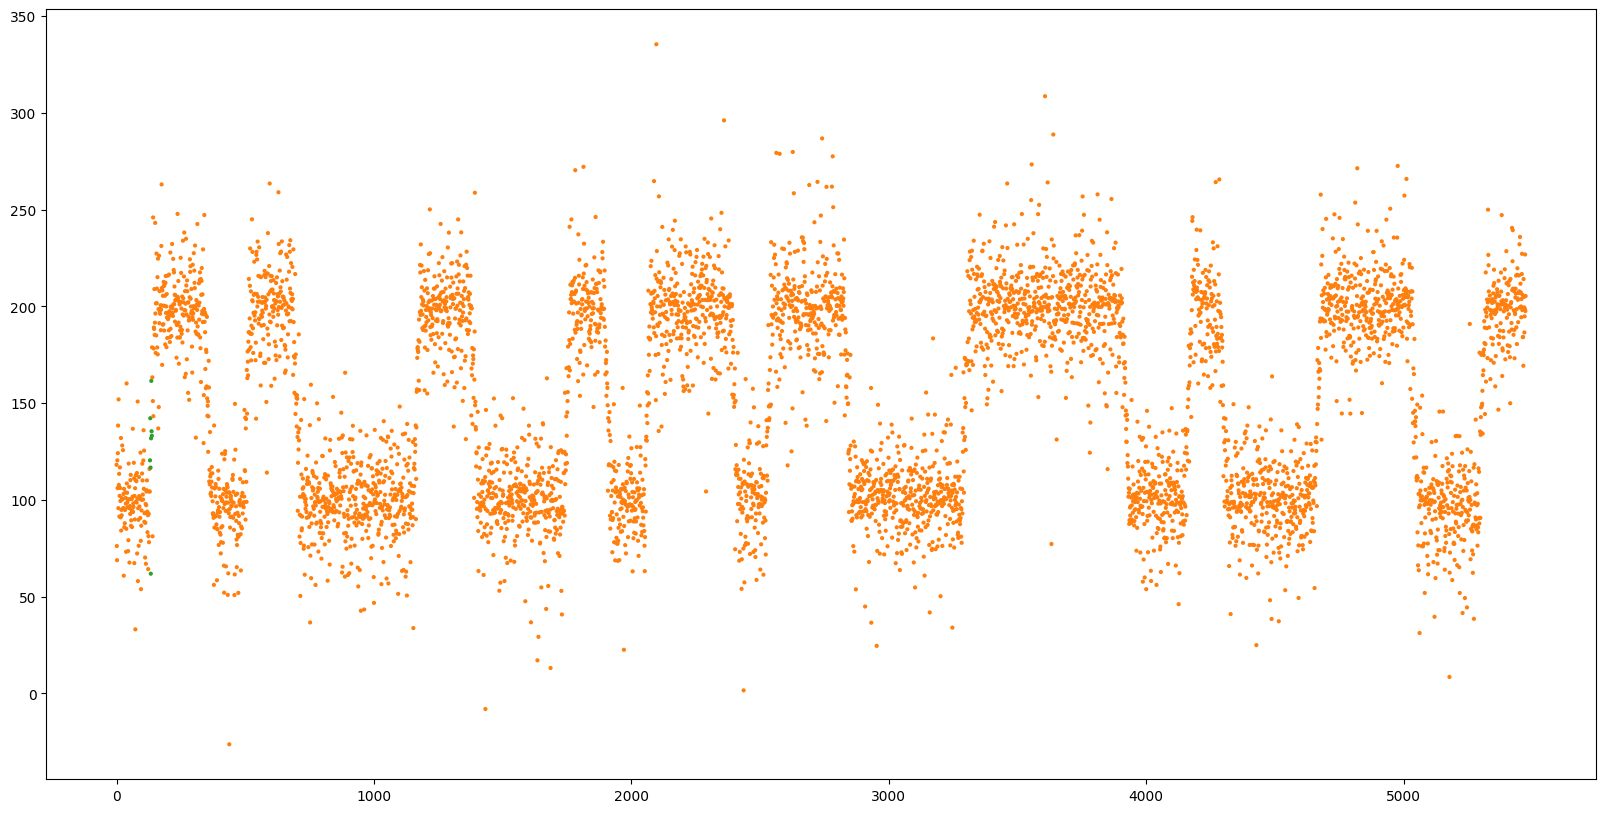

In [8]:
data = sc_df
N = 3
fig = plt.figure(figsize=(20,10))
top_labels = data['label'].value_counts().head(N).index
colors = ['grey' if l not in top_labels else plt.cm.tab10(l) for l in data['label']]
plt.scatter(data['time'], data['value'], c=colors, s=4)
plt.savefig("toy-spectral-clustering.pdf")
plt.show()

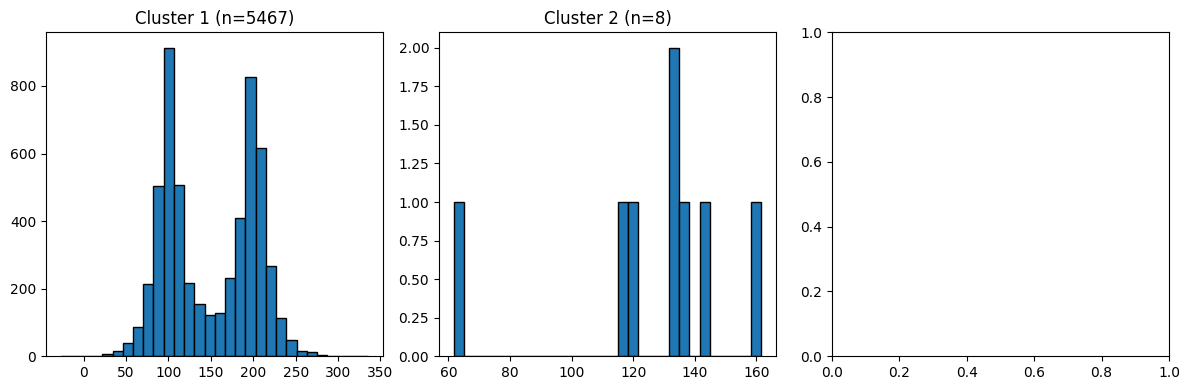

In [9]:
N = 3
top_labels = data['label'].value_counts().head(N).index
fig, axes = plt.subplots(1,3, figsize=(12, 4))
ticks = [-2.0 + n*0.5 for n in range(9)]
for i, label in enumerate(top_labels):
    ax = axes[i]
    cluster_data = data[data['label'] == label]['value']
    ax.hist(cluster_data, bins=30, edgecolor='black')
    ax.set_title(f'Cluster {label} (n={len(cluster_data)})')
    #ax.set_xticks(ticks)
plt.tight_layout()
plt.savefig("toy-spectral-distributions.pdf")
plt.show()

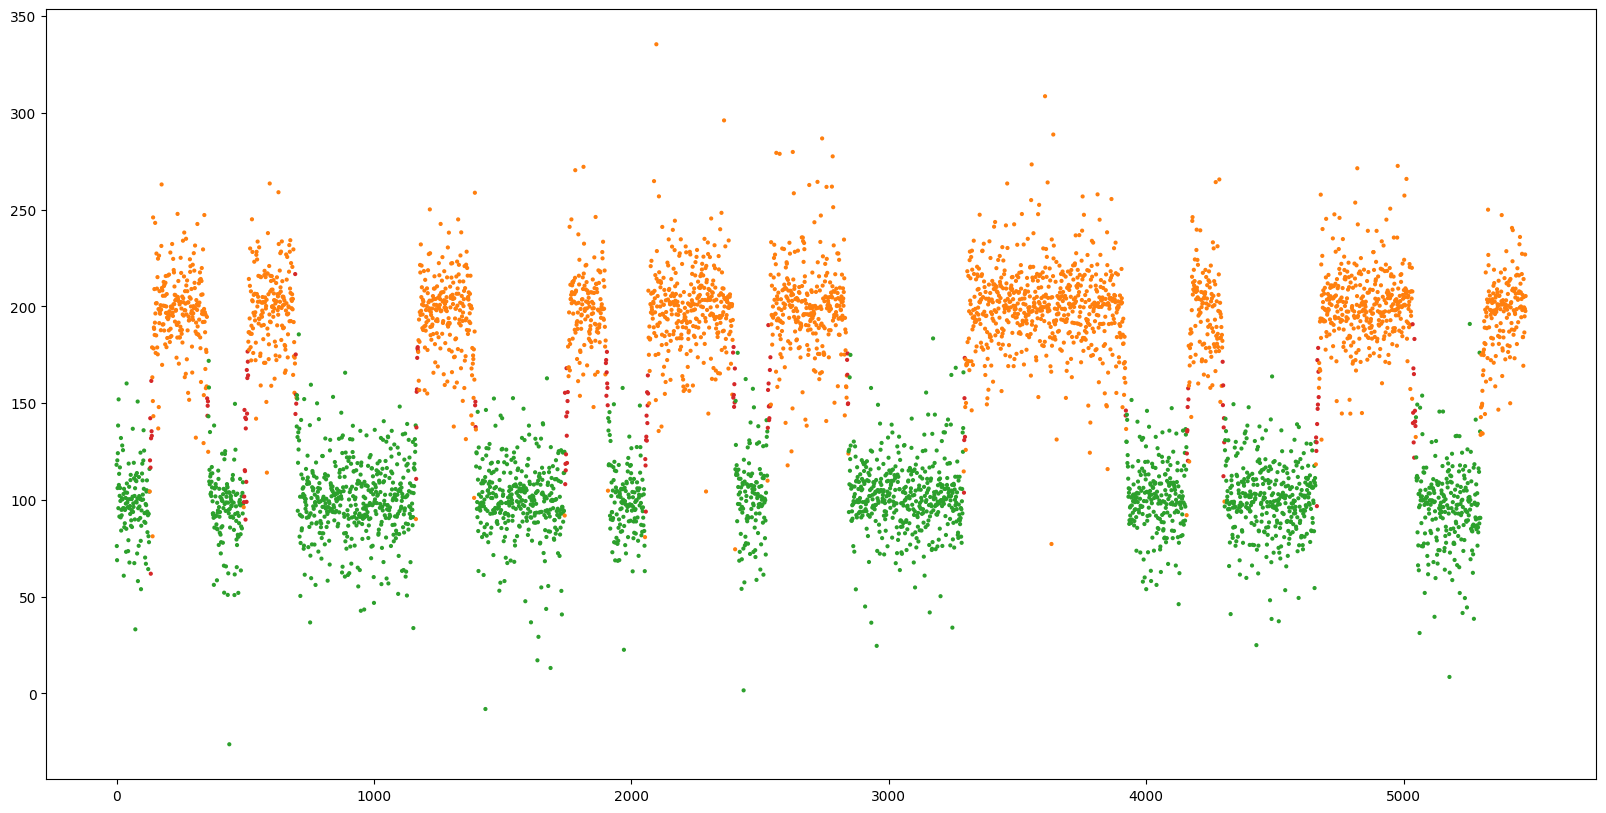

In [10]:
data = adpc_df
N = 3
fig = plt.figure(figsize=(20,10))
top_labels = data['label'].value_counts().head(N).index
colors = ['grey' if l not in top_labels else plt.cm.tab10(l) for l in data['label']]
plt.scatter(data['time'], data['value'], c=colors, s=4, rasterized=True)
plt.savefig("toy-adpc-clustering.pdf")
plt.show()

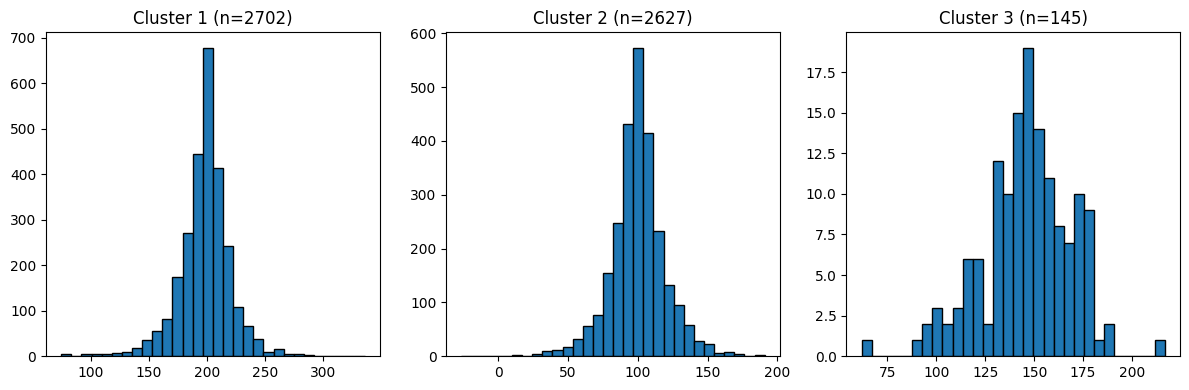

In [11]:
N = 3
top_labels = df['label'].value_counts().head(N).index
fig, axes = plt.subplots(1,3, figsize=(12, 4))
ticks = [-2.0 + n*0.5 for n in range(9)]
for i, label in enumerate(top_labels):
    ax = axes[i]
    cluster_data = df[df['label'] == label]['value']
    ax.hist(cluster_data, bins=30, edgecolor='black')
    ax.set_title(f'Cluster {label} (n={len(cluster_data)})')
#    ax.set_xticks(ticks)
plt.tight_layout()
plt.savefig("toy-adpc-distributions.pdf")
plt.show()

100%|██████████████████████████████████████| 780/780 [00:00<00:00, 10059.49it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


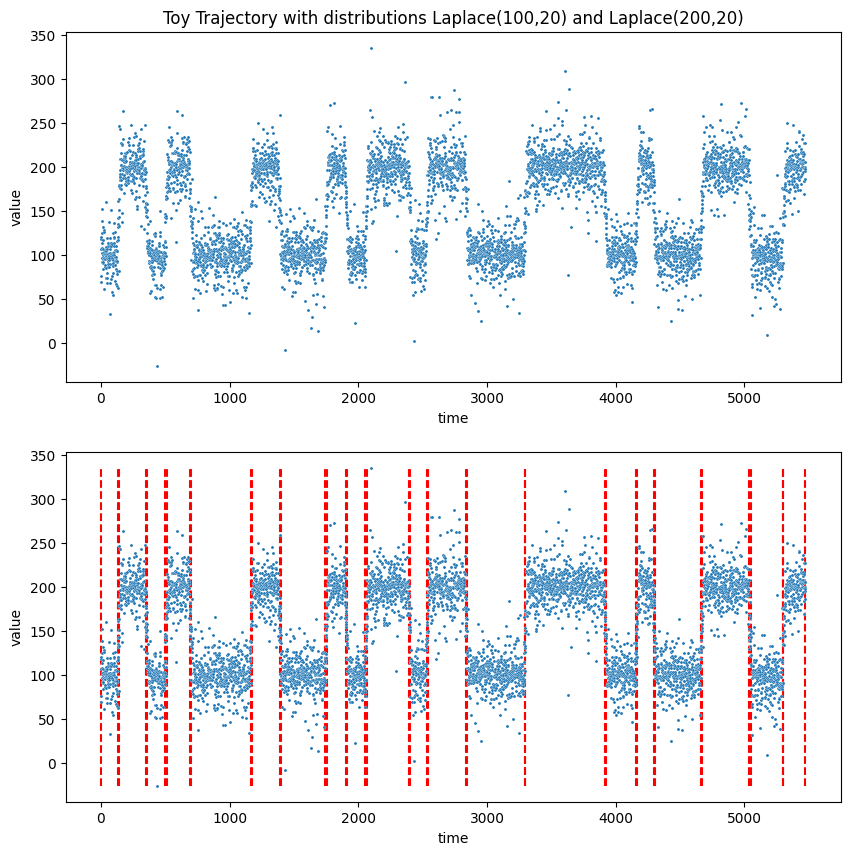

In [12]:
# fit wit SC
sc_sbc = SegmentBasedCluster(window_size=w, quantile=q, method="spectral", num_clusters=3)
sc_sbc.fit(x)
segment_labels = sc_sbc.segment_labels_
labels = sc_sbc.point_labels_
sc_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": labels})

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
# uncolored
sns.scatterplot(ax=ax[0], data=sc_df, x="time", y="value", s=5, rasterized=True)
ax[0].set_title("Toy Trajectory with distributions Laplace(100,20) and Laplace(200,20)")
# uncolored
sns.scatterplot(ax=ax[1], data=sc_df, x="time", y="value", s=5, rasterized=True)
#ax[1].set_title("Toy Trajectory with distributions Laplace(100,20) and Laplace(200,20)")
ax[1].vlines(np.where(sc_sbc.change_points_!=0)[0], ymin=np.min(x), ymax=np.max(x), color="red", linestyle="--", zorder=0)
#plt.savefig("toy-traj-cps.pdf", bbox_inches="tight")
plt.savefig("toy-traj-cps.png", dpi=900, bbox_inches="tight")

100%|███████████████████████████████████████| 780/780 [00:00<00:00, 9835.93it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/dadapy/kstar.py:101: UserWarning: Careful! The intrinsic dimension is not defined. Computing it unsupervisedly with 'compute_id_2NN()' method
  warnings.warn(


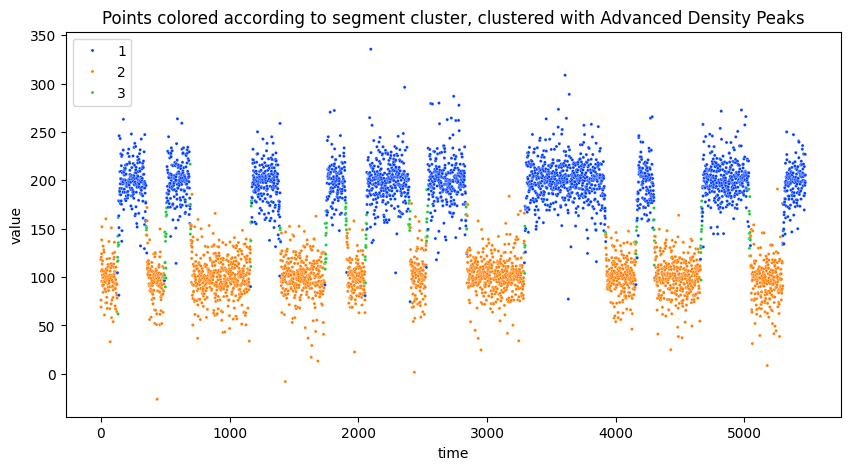

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

# refit with ADPC
adpc_sbc = SegmentBasedCluster(window_size=w, quantile=q)
adpc_sbc.fit(x)
segment_labels = adpc_sbc.segment_labels_
labels = adpc_sbc.point_labels_
adpc_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": labels})

# colored by ADPC
sns.scatterplot(ax=ax, data=adpc_df, x="time", y="value", hue="label", palette="bright", s = 5, rasterized=True)
ax.set_title("Points colored according to segment cluster, clustered with Advanced Density Peaks")
plt.legend(loc="upper left")

# save fig
#plt.savefig("toy-traj-adpc.pdf", bbox_inches="tight")
plt.savefig("toy-traj-adpc.png", dpi=900, bbox_inches="tight")

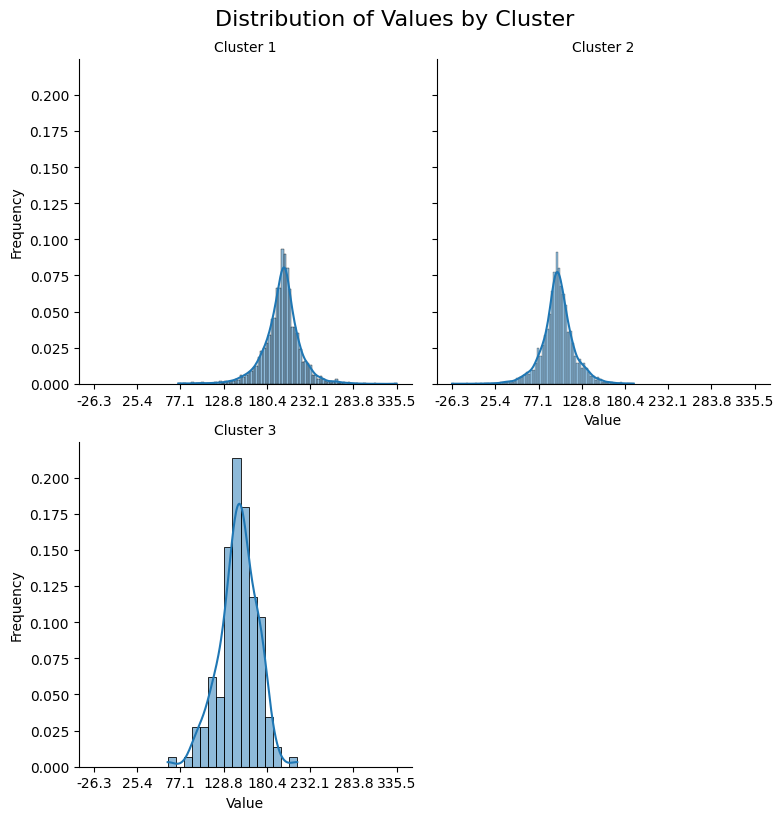

In [14]:
df = adpc_df
n_clusters = len(df["label"].unique())
g = sns.FacetGrid(df, col="label", col_wrap=2, height=4)
g.map(sns.histplot, "value", kde=True, stat="probability")
g.set_axis_labels("Value", "Frequency")
g.set_titles("Cluster {col_name}")
data_min, data_max = df['value'].min(), df['value'].max()
xticks = np.linspace(data_min, data_max, 8)  # 8 evenly spaced ticks
g.fig.suptitle("Distribution of Values by Cluster", fontsize=16, y=1.02)

# Apply ticks and labels to ALL subplots
for ax in g.axes.flat:
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{x:.1f}' for x in xticks])  # format labels to 1 decimal
    ax.tick_params(labelbottom=True)
#plt.savefig("toy-cluster-distributions.pdf", bbox_inches="tight")
plt.savefig("toy-cluster-distributions.png", dpi=900, bbox_inches="tight")

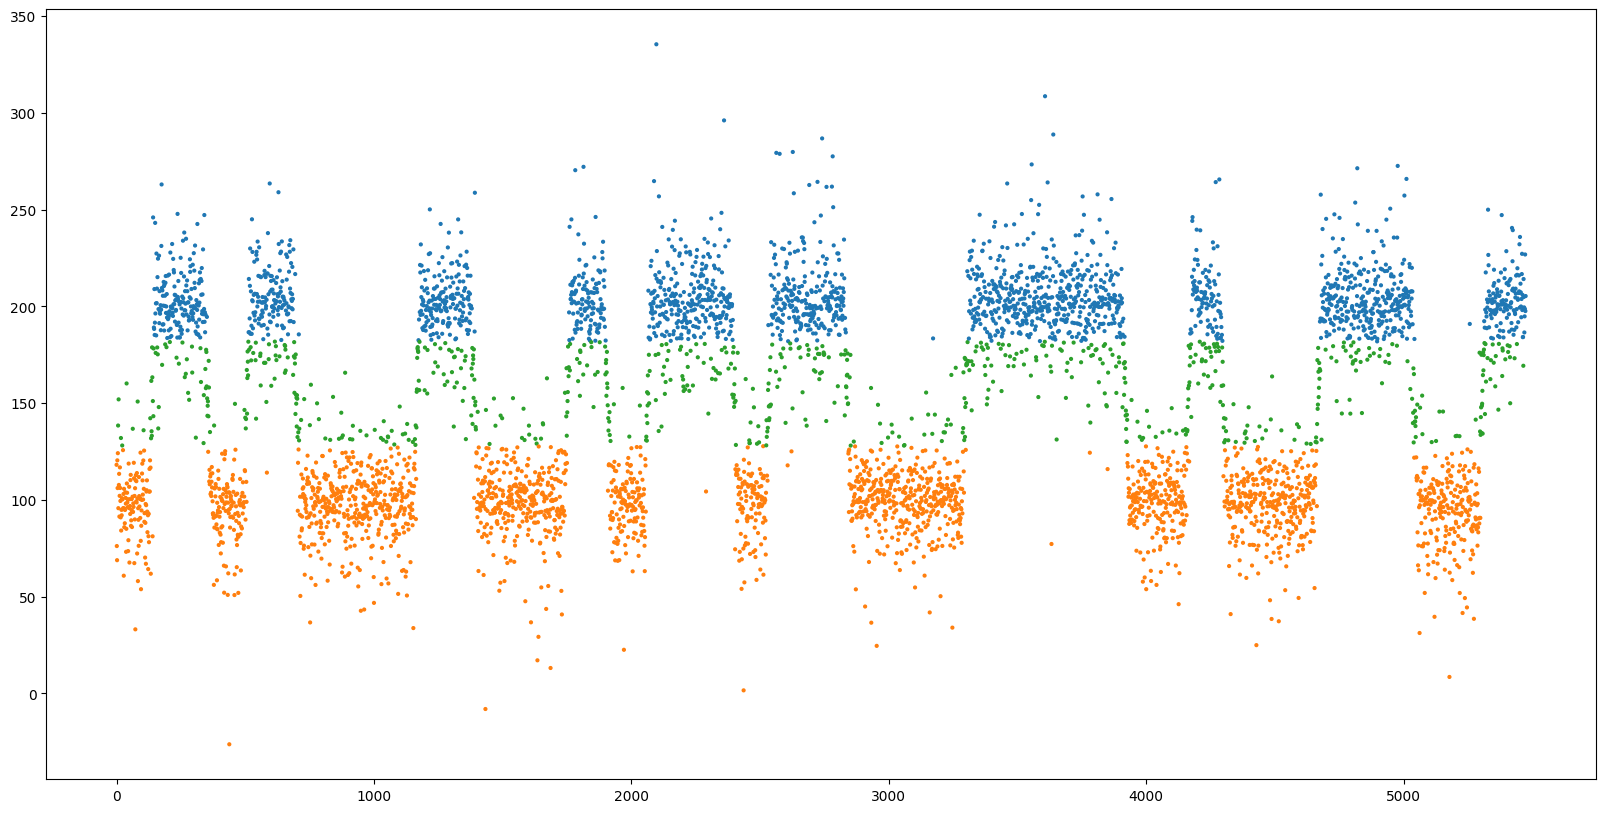

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(init="k-means++", n_clusters=3, n_init=4)
kmeans.fit(x)
kmeans.labels_.reshape(-1,1).shape


kmeans_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": kmeans.labels_})
data = kmeans_df
N = 3
fig = plt.figure(figsize=(20,10))
top_labels = data['label'].value_counts().head(N).index
colors = ['grey' if l not in top_labels else plt.cm.tab10(l) for l in data['label']]
plt.scatter(data['time'], data['value'], c=colors, s=4, rasterized=True)
plt.savefig("toy-kmeans-clustering.pdf", bbox_inches="tight")
plt.show()


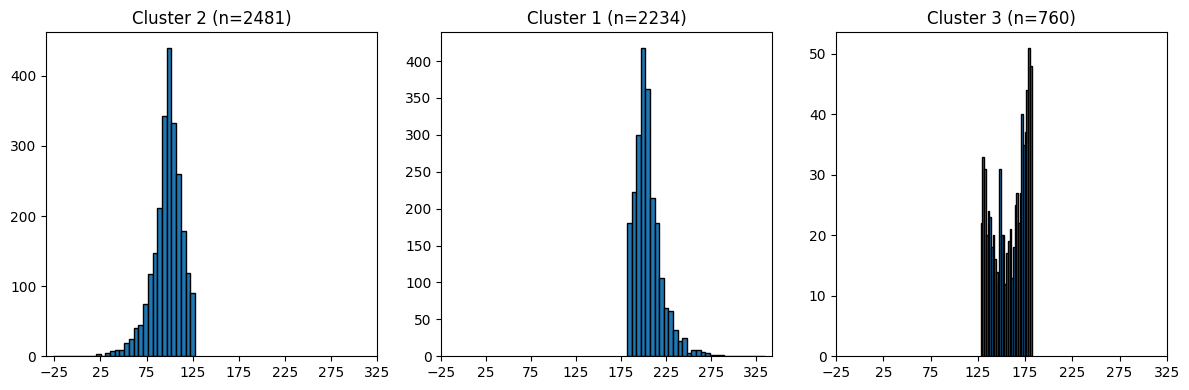

In [16]:
data = kmeans_df
N = 3
top_labels = data['label'].value_counts().head(N).index
fig, axes = plt.subplots(1,3, figsize=(12, 4))
ticks = [-25 + n*50 for n in range(8)]
for i, label in enumerate(top_labels):
    ax = axes[i]
    cluster_data = data[data['label'] == label]['value']
    ax.hist(cluster_data, bins=30, edgecolor='black')
    ax.set_title(f'Cluster {label + 1} (n={len(cluster_data)})')
    ax.set_xticks(ticks)
plt.tight_layout()
plt.savefig("toy-kmeans-distributions.pdf")
plt.show()